<a href="https://colab.research.google.com/github/siddKatiyar09/online-retail-crm-analysis/blob/main/Online_Retail_CRM_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Online Retail CRM Analysis

This beginner-friendly project studies online retail transactions and groups customers
using **RFM analysis** and **K-means clustering**.

## Questions answered

1. How clean is the dataset?
2. When and where does the business earn the most revenue?
3. Which products generate the most revenue?
4. Who are the best customers?
5. How can customers be grouped for marketing campaigns?

The code is written in small steps so a college student can run and explain every section.

## 1. Import libraries

We use pandas for data analysis, matplotlib and seaborn for charts, and scikit-learn
for customer clustering.

In [38]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:,.2f}".format)

# DATA_PATH = Path("data/OnlineRetail.csv")
OUTPUT_PATH = Path("output")
OUTPUT_PATH.mkdir(exist_ok=True)

print("Libraries loaded successfully.")
# print(f"Dataset path: {DATA_PATH.resolve()}")

Libraries loaded successfully.


## 2. Load the dataset

The CSV file should be inside the project's `data` folder and named `OnlineRetail.csv`.

In [17]:
# retail = pd.read_csv(DATA_PATH, encoding="ISO-8859-1")
retail = pd.read_csv('/content/OnlineRetail.csv', encoding="ISO-8859-1")
print(f"Rows: {retail.shape[0]:,}")
print(f"Columns: {retail.shape[1]}")
display(retail.head())

Rows: 288,707
Columns: 8


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom


## 3. Understand the data

Before cleaning, we check column types, missing values, duplicates, returns, and invalid prices.

In [18]:
retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288707 entries, 0 to 288706
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    288707 non-null  object 
 1   StockCode    288707 non-null  object 
 2   Description  287622 non-null  object 
 3   Quantity     288707 non-null  int64  
 4   InvoiceDate  288707 non-null  object 
 5   UnitPrice    288706 non-null  float64
 6   CustomerID   207055 non-null  float64
 7   Country      288706 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 17.6+ MB


In [19]:
missing_values = (
    retail.isna()
    .sum()
    .to_frame("Missing Values")
    .assign(Percentage=lambda table: table["Missing Values"] / len(retail) * 100)
    .sort_values("Missing Values", ascending=False)
)

display(missing_values)

,Missing Values,Percentage
CustomerID,81652,28.28
Description,1085,0.38
UnitPrice,1,0.00
Country,1,0.00
Quantity,0,0.00
StockCode,0,0.00
InvoiceNo,0,0.00
InvoiceDate,0,0.00


In [20]:
data_issues = pd.DataFrame(
    {
        "Issue": [
            "Duplicate rows",
            "Missing CustomerID",
            "Cancelled invoices",
            "Negative or zero quantity",
            "Negative or zero price",
        ],
        "Rows": [
            retail.duplicated().sum(),
            retail["CustomerID"].isna().sum(),
            retail["InvoiceNo"].astype(str).str.startswith("C").sum(),
            (retail["Quantity"] <= 0).sum(),
            (retail["UnitPrice"] <= 0).sum(),
        ],
    }
)

display(data_issues)

,Issue,Rows
0,Duplicate rows,2272
1,Missing CustomerID,81652
2,Cancelled invoices,5244
3,Negative or zero quantity,6126
4,Negative or zero price,1676


## 4. Clean the data

For customer analysis, we remove duplicate rows, anonymous customers, cancelled orders,
returned items, and rows with invalid prices. We also create a `Revenue` column.

In [21]:
clean_retail = retail.copy()
starting_rows = len(clean_retail)

clean_retail["InvoiceDate"] = pd.to_datetime(
    clean_retail["InvoiceDate"], format="%m/%d/%Y %H:%M"
)
clean_retail = clean_retail.drop_duplicates()
clean_retail = clean_retail.dropna(subset=["CustomerID", "Description"])
clean_retail = clean_retail[
    ~clean_retail["InvoiceNo"].astype(str).str.startswith("C")
]
clean_retail = clean_retail[
    (clean_retail["Quantity"] > 0) & (clean_retail["UnitPrice"] > 0)
].copy()

clean_retail["CustomerID"] = clean_retail["CustomerID"].astype(int)
clean_retail["Revenue"] = clean_retail["Quantity"] * clean_retail["UnitPrice"]

cleaning_summary = pd.DataFrame(
    {
        "Measure": ["Rows before cleaning", "Rows after cleaning", "Rows removed"],
        "Value": [
            starting_rows,
            len(clean_retail),
            starting_rows - len(clean_retail),
        ],
    }
)

display(cleaning_summary)
display(clean_retail.head())

,Measure,Value
0,Rows before cleaning,288707
1,Rows after cleaning,199839
2,Rows removed,88868


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## 5. Key business numbers

These numbers give a quick overview of the cleaned sales data.

In [22]:
total_revenue = clean_retail["Revenue"].sum()
total_orders = clean_retail["InvoiceNo"].nunique()
total_customers = clean_retail["CustomerID"].nunique()
average_order_value = total_revenue / total_orders

kpis = pd.DataFrame(
    {
        "KPI": [
            "Total Revenue",
            "Total Orders",
            "Total Customers",
            "Average Order Value",
        ],
        "Value": [
            f"${total_revenue:,.2f}",
            f"{total_orders:,}",
            f"{total_customers:,}",
            f"${average_order_value:,.2f}",
        ],
    }
)

display(kpis)

,KPI,Value
0,Total Revenue,"$4,638,971.28"
1,Total Orders,"10,246"
2,Total Customers,"3,173"
3,Average Order Value,$452.76


## 6. Exploratory data analysis

### Monthly revenue

This chart shows sales growth and seasonality over time.

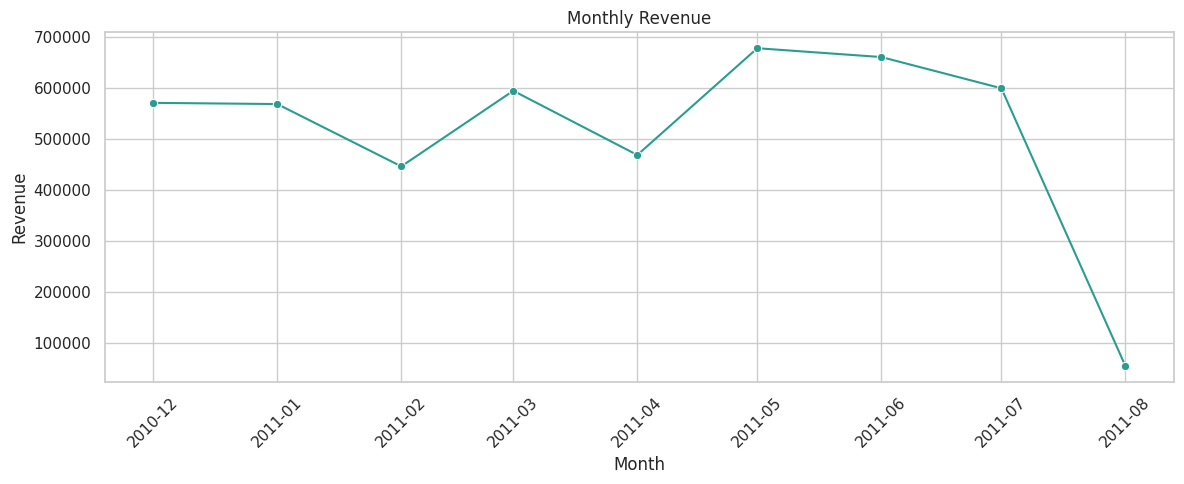

,Month,Revenue
0,2010-12-01,"570,422.73"
1,2011-01-01,"568,101.31"
2,2011-02-01,"446,084.92"
3,2011-03-01,"594,081.76"
4,2011-04-01,"468,374.33"
5,2011-05-01,"677,355.15"
6,2011-06-01,"660,046.05"
7,2011-07-01,"598,962.90"
8,2011-08-01,"55,542.13"


In [23]:
monthly_revenue = (
    clean_retail.assign(
        Month=clean_retail["InvoiceDate"].dt.to_period("M").dt.to_timestamp()
    )
    .groupby("Month", as_index=False)["Revenue"]
    .sum()
)

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_revenue, x="Month", y="Revenue", marker="o", color="#2a9d8f")
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(monthly_revenue)

### Revenue by country

The chart compares the ten countries that generate the most revenue.

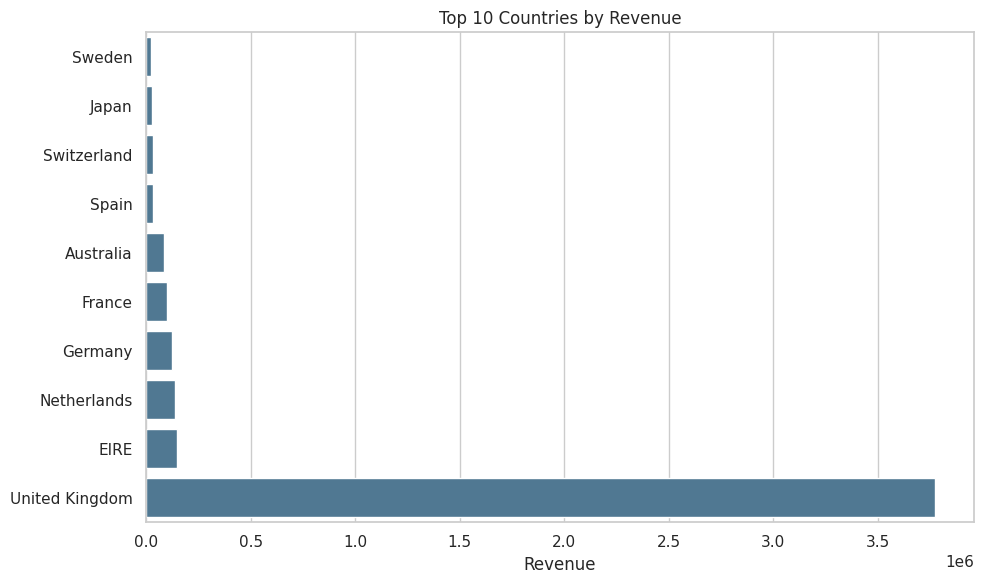

,Country,Revenue
34,United Kingdom,"3,771,773.62"
10,EIRE,"146,741.74"
23,Netherlands,"139,870.59"
14,Germany,"126,243.38"
13,France,"99,758.39"
0,Australia,"86,464.63"
29,Spain,"35,404.70"
31,Switzerland,"31,423.67"
19,Japan,"26,896.17"
30,Sweden,"23,675.87"


In [24]:
top_countries = (
    clean_retail.groupby("Country", as_index=False)["Revenue"]
    .sum()
    .nlargest(10, "Revenue")
    .sort_values("Revenue")
)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_countries, x="Revenue", y="Country", color="#457b9d")
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("")
plt.tight_layout()
plt.show()

display(top_countries.sort_values("Revenue", ascending=False))

### Best-selling products

Product revenue helps identify items for promotions, recommendations, and bundles.

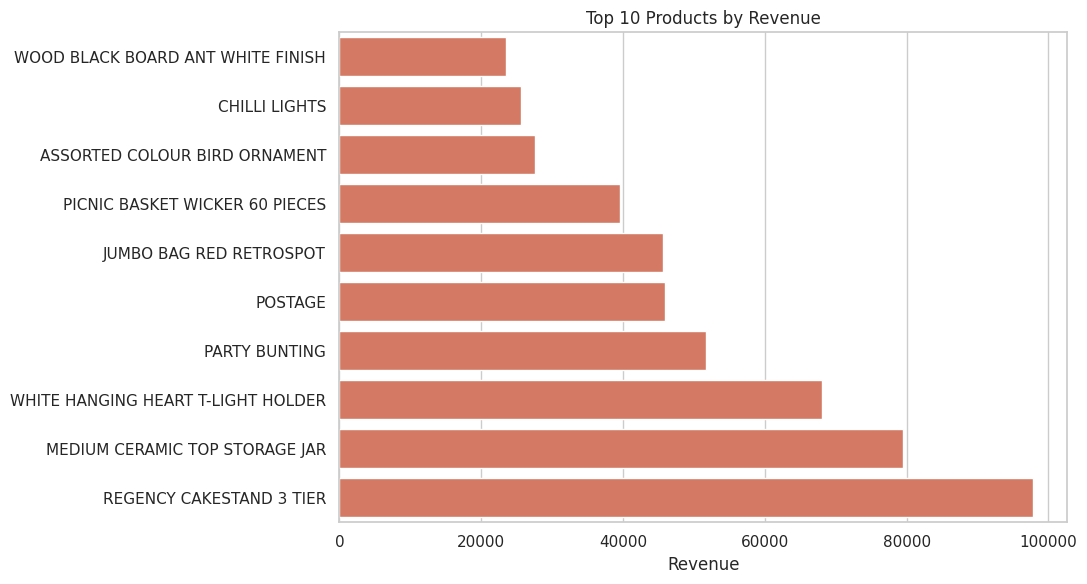

,Description,Revenue
2505,REGENCY CAKESTAND 3 TIER,"97,791.25"
1801,MEDIUM CERAMIC TOP STORAGE JAR,"79,443.09"
3296,WHITE HANGING HEART T-LIGHT HOLDER,"68,126.39"
2109,PARTY BUNTING,"51,760.85"
2356,POSTAGE,"45,922.01"
1602,JUMBO BAG RED RETROSPOT,"45,640.68"
2154,PICNIC BASKET WICKER 60 PIECES,"39,619.50"
190,ASSORTED COLOUR BIRD ORNAMENT,"27,562.44"
670,CHILLI LIGHTS,"25,553.61"
3341,WOOD BLACK BOARD ANT WHITE FINISH,"23,470.45"


In [25]:
top_products = (
    clean_retail.groupby("Description", as_index=False)["Revenue"]
    .sum()
    .nlargest(10, "Revenue")
    .sort_values("Revenue")
)

plt.figure(figsize=(11, 6))
sns.barplot(data=top_products, x="Revenue", y="Description", color="#e76f51")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("")
plt.tight_layout()
plt.show()

display(top_products.sort_values("Revenue", ascending=False))

### Orders by day of the week

This chart shows when customers place the most orders.

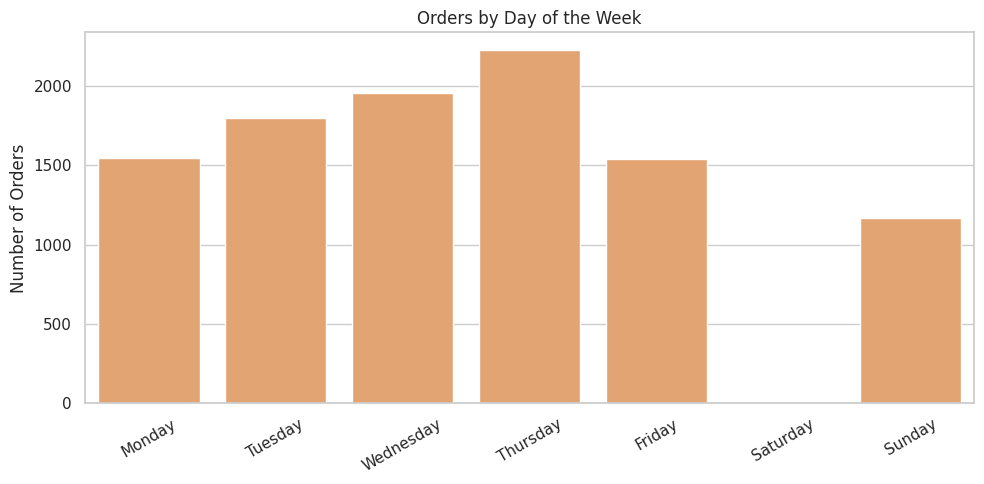

,Day,Orders
0,Monday,1550
1,Tuesday,1799
2,Wednesday,1957
3,Thursday,2228
4,Friday,1543
5,Saturday,0
6,Sunday,1169


In [26]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
orders_by_day = (
    clean_retail.assign(Day=clean_retail["InvoiceDate"].dt.day_name())
    .groupby("Day")["InvoiceNo"]
    .nunique()
    .reindex(day_order, fill_value=0)
    .reset_index(name="Orders")
)

plt.figure(figsize=(10, 5))
sns.barplot(data=orders_by_day, x="Day", y="Orders", color="#f4a261")
plt.title("Orders by Day of the Week")
plt.xlabel("")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

display(orders_by_day)

## 7. Build the RFM customer table

RFM uses three simple measures:

- **Recency:** days since the customer's last purchase. Lower is better.
- **Frequency:** number of different orders. Higher is better.
- **Monetary:** total amount spent. Higher is better.

In [27]:
snapshot_date = clean_retail["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = (
    clean_retail.groupby("CustomerID")
    .agg(
        Recency=("InvoiceDate", lambda dates: (snapshot_date - dates.max()).days),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("Revenue", "sum"),
    )
    .reset_index()
)

display(rfm.head())
display(rfm[["Recency", "Frequency", "Monetary"]].describe())

,CustomerID,Recency,Frequency,Monetary
0,12346,198,1,"77,183.60"
1,12347,2,5,"2,790.86"
2,12348,121,3,"1,487.24"
3,12350,182,1,334.40
4,12352,134,5,"1,561.81"


,Recency,Frequency,Monetary
count,"3,173.00","3,173.00","3,173.00"
mean,82.67,3.23,"1,462.01"
std,68.92,5.14,"5,317.98"
min,1.00,1.00,2.90
25%,24.00,1.00,252.45
50%,62.00,2.00,532.94
75%,129.00,3.00,"1,249.87"
max,246.00,116.00,"136,028.13"


## 8. Give customers RFM scores and segments

Each RFM measure receives a score from 1 to 4. The three scores are added together,
and the total is converted into an easy-to-understand customer segment.

In [28]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"].rank(method="first"), 4, labels=[4, 3, 2, 1]
).astype(int)
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4]
).astype(int)
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"), 4, labels=[1, 2, 3, 4]
).astype(int)
rfm["RFM_Score"] = rfm[["R_Score", "F_Score", "M_Score"]].sum(axis=1)

def assign_segment(score):
    if score >= 10:
        return "Champions"
    if score >= 8:
        return "Loyal Customers"
    if score >= 6:
        return "Potential Loyalists"
    if score >= 5:
        return "Needs Attention"
    return "At Risk"

rfm["Segment"] = rfm["RFM_Score"].apply(assign_segment)

segment_summary = (
    rfm.groupby("Segment")
    .agg(
        Customers=("CustomerID", "count"),
        Average_Recency=("Recency", "mean"),
        Average_Frequency=("Frequency", "mean"),
        Average_Spend=("Monetary", "mean"),
        Total_Revenue=("Monetary", "sum"),
    )
    .sort_values("Total_Revenue", ascending=False)
)

display(segment_summary.round(2))

,Customers,Average_Recency,Average_Frequency,Average_Spend,Total_Revenue
Segment,,,,,
Champions,899,25.19,7.32,"3,761.34","3,381,446.87"
Loyal Customers,653,57.16,2.55,955.83,"624,159.49"
Potential Loyalists,671,84.20,1.51,601.57,"403,653.53"
Needs Attention,382,124.00,1.10,312.69,"119,448.84"
At Risk,568,173.38,1.01,194.12,"110,262.55"


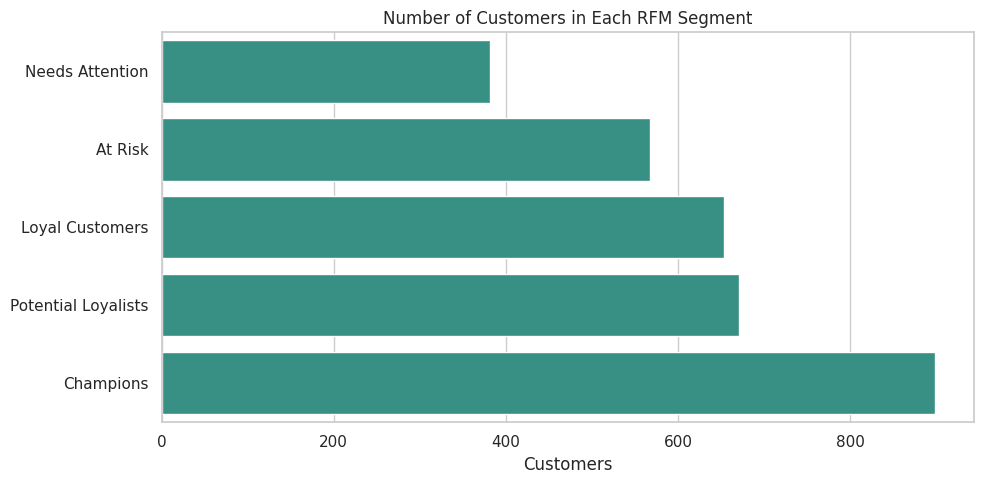

In [29]:
segment_counts = rfm["Segment"].value_counts().sort_values()

plt.figure(figsize=(10, 5))
sns.barplot(x=segment_counts.values, y=segment_counts.index, color="#2a9d8f")
plt.title("Number of Customers in Each RFM Segment")
plt.xlabel("Customers")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 9. K-means customer clustering

K-means is a machine-learning method that groups customers with similar behavior.
Because RFM values are very different in size, we log-transform and standardize them first.

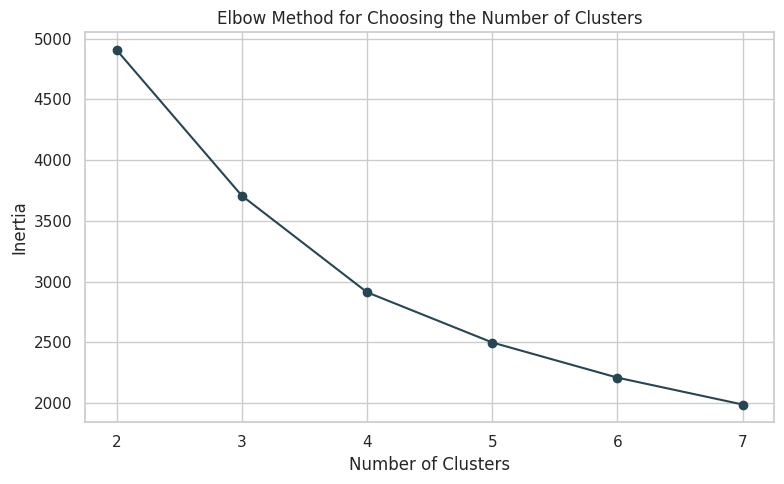

In [30]:
cluster_features = np.log1p(rfm[["Recency", "Frequency", "Monetary"]])
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features)

inertia_values = []
cluster_options = range(2, 8)

for number_of_clusters in cluster_options:
    model = KMeans(n_clusters=number_of_clusters, random_state=42, n_init=10)
    model.fit(scaled_features)
    inertia_values.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(cluster_options), inertia_values, marker="o", color="#264653")
plt.title("Elbow Method for Choosing the Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.xticks(list(cluster_options))
plt.tight_layout()
plt.show()

In [31]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(scaled_features)

cluster_summary = (
    rfm.groupby("Cluster")
    .agg(
        Customers=("CustomerID", "count"),
        Average_Recency=("Recency", "mean"),
        Average_Frequency=("Frequency", "mean"),
        Average_Spend=("Monetary", "mean"),
        Total_Revenue=("Monetary", "sum"),
    )
    .round(2)
    .sort_values("Average_Spend", ascending=False)
)

display(cluster_summary)

,Customers,Average_Recency,Average_Frequency,Average_Spend,Total_Revenue
Cluster,,,,,
1,424,18.61,11.25,"6,488.55","2,751,146.91"
3,931,73.54,3.10,"1,281.66","1,193,229.18"
0,479,13.11,2.19,685.54,"328,372.35"
2,1339,134.20,1.15,273.50,"366,222.84"


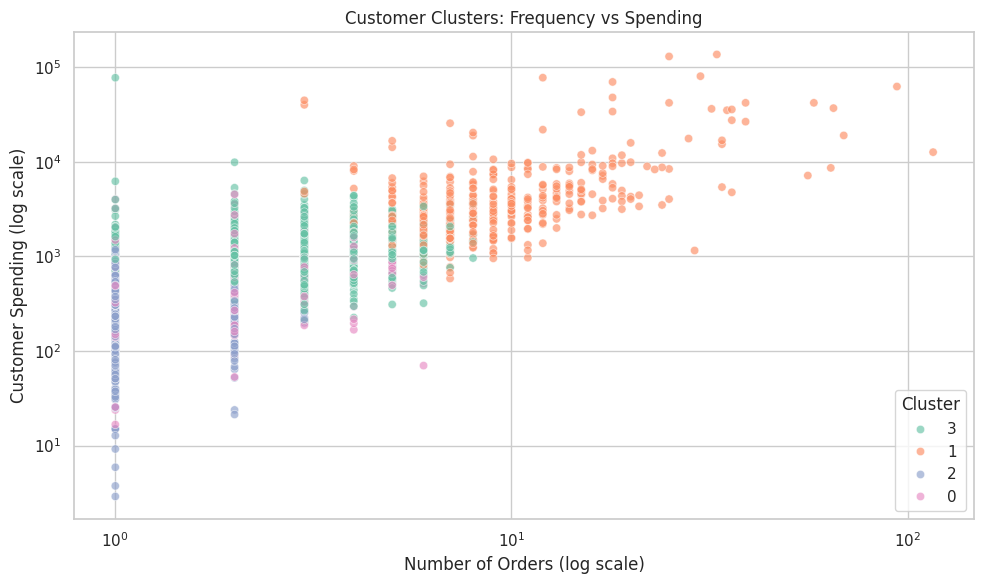

In [32]:
plot_data = rfm.copy()
plot_data["Cluster"] = plot_data["Cluster"].astype(str)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_data,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    alpha=0.65,
    palette="Set2",
)
plt.xscale("log")
plt.yscale("log")
plt.title("Customer Clusters: Frequency vs Spending")
plt.xlabel("Number of Orders (log scale)")
plt.ylabel("Customer Spending (log scale)")
plt.tight_layout()
plt.show()

## 10. Simple marketing recommendations

The RFM segments are easier to explain to a business than cluster numbers, so we use them
to suggest practical customer campaigns.

In [33]:
recommendations = pd.DataFrame(
    {
        "Segment": [
            "Champions",
            "Loyal Customers",
            "Potential Loyalists",
            "Needs Attention",
            "At Risk",
        ],
        "Recommended Action": [
            "Offer VIP rewards, early access, and referral benefits.",
            "Use loyalty rewards, product bundles, and cross-selling.",
            "Encourage a second or third purchase with personalized offers.",
            "Send reminders and limited-time re-engagement discounts.",
            "Run a win-back campaign and ask why the customer stopped buying.",
        ],
    }
)

display(recommendations)

,Segment,Recommended Action
0,Champions,"Offer VIP rewards, early access, and referral ..."
1,Loyal Customers,"Use loyalty rewards, product bundles, and cros..."
2,Potential Loyalists,Encourage a second or third purchase with pers...
3,Needs Attention,Send reminders and limited-time re-engagement ...
4,At Risk,Run a win-back campaign and ask why the custom...


## 11. Save the customer results

The final CSV can be used in Excel, Power BI, Tableau, or a simple CRM dashboard.

In [40]:
result_file = OUTPUT_PATH / "/content/customer_segments_simple.csv"
rfm.to_csv(result_file, index=False)

print(f"Saved {len(rfm):,} customer records to:")
print(result_file.resolve())
display(rfm.head(10))

Saved 3,173 customer records to:
/content/customer_segments_simple.csv


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment,Cluster
0,12346,198,1,"77,183.60",1,1,4,6,Potential Loyalists,3
1,12347,2,5,"2,790.86",4,4,4,12,Champions,1
2,12348,121,3,"1,487.24",2,3,4,9,Loyal Customers,3
3,12350,182,1,334.40,1,1,2,4,At Risk,2
4,12352,134,5,"1,561.81",1,4,4,9,Loyal Customers,3
5,12353,76,1,89.00,2,1,1,4,At Risk,2
6,12354,104,1,"1,079.40",2,1,3,6,Potential Loyalists,3
7,12355,86,1,459.40,2,1,2,5,Needs Attention,2
8,12356,118,2,"2,753.08",2,2,4,8,Loyal Customers,3
9,12358,23,1,484.86,4,1,2,7,Potential Loyalists,0


## 12. Final conclusions

- Cleaning is necessary because the raw data contains anonymous purchases, returns, and duplicates.
- Monthly and country charts explain when and where revenue is generated.
- RFM analysis turns transaction history into clear customer groups.
- K-means provides a second, machine-learning view of customer behavior.
- The exported customer table can support targeted marketing campaigns.

